Importation du dataset

In [ ]:
chemin = "/content/drive/MyDrive/gym_members_exercise_tracking.csv"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv(chemin)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [ ]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


Importation de matplotlib et de seaborn

Graphique du BPM maximum en fonction du Poids

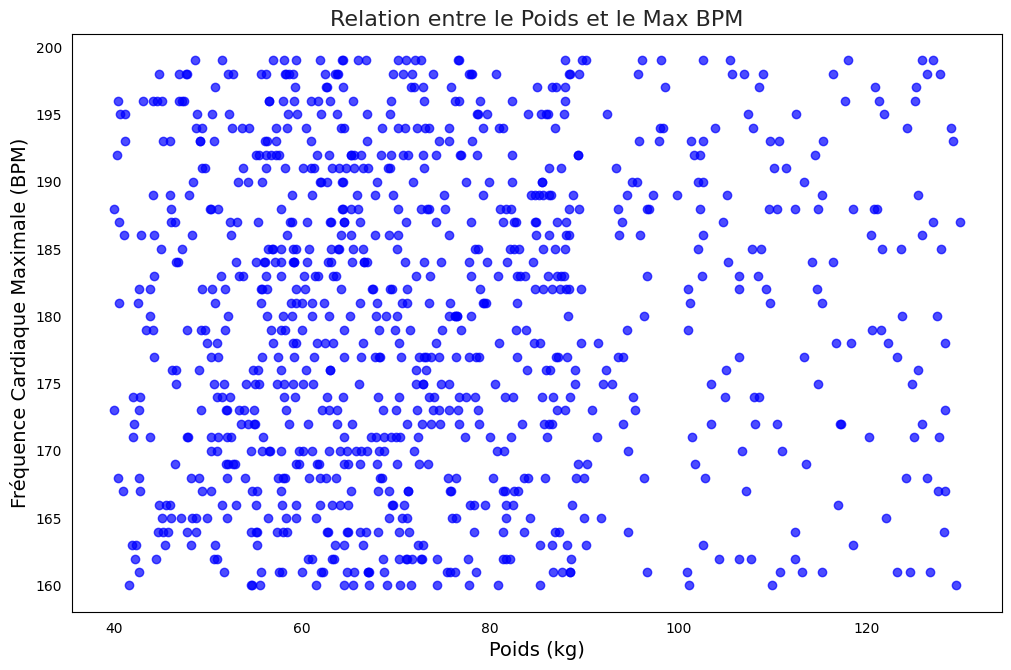

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style et des paramètres
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 7.5)
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Création du graphique de dispersion
plt.figure(figsize=(12, 7.5))
plt.scatter(df['Weight (kg)'], df['Max_BPM'], color='blue', alpha=0.7)

# Ajout des étiquettes et du titre
plt.title('Relation entre le Poids et le Max BPM', fontsize=16)
plt.xlabel('Poids (kg)', fontsize=14)
plt.ylabel('Fréquence Cardiaque Maximale (BPM)', fontsize=14)

# Affichage du graphique
plt.show()


Calories brulées en fontion du temps de Session Homme/Femme

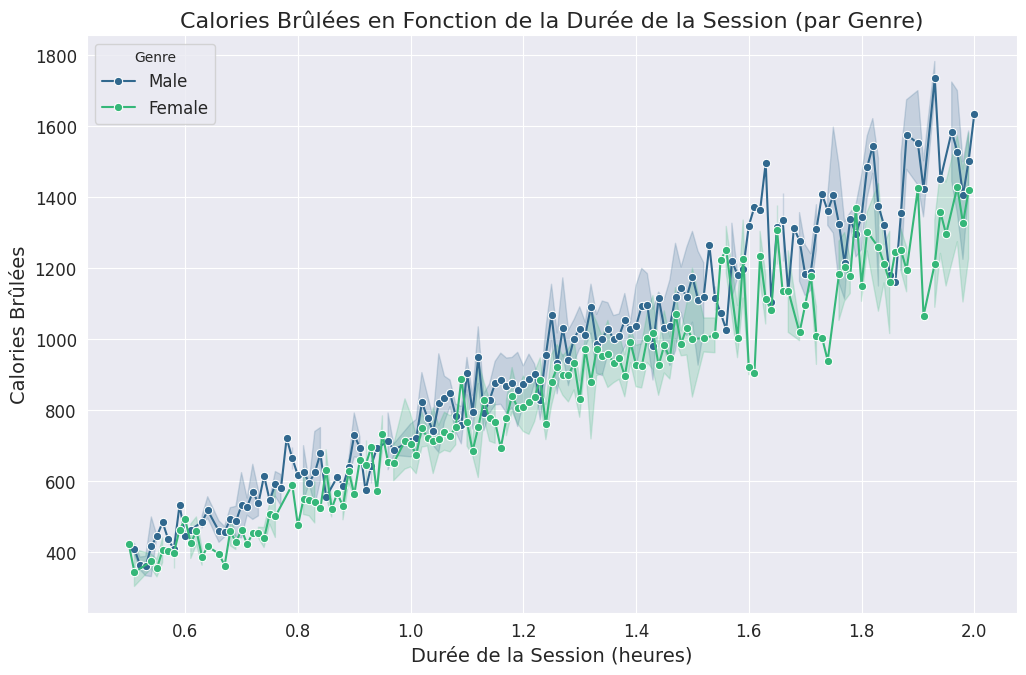

In [ ]:
# Configuration du style
sns.set_style('darkgrid')
plt.figure(figsize=(12, 7.5))

# Graphique linéaire
sns.lineplot(
    data=df,
    x='Session_Duration (hours)',
    y='Calories_Burned',
    hue='Gender',
    marker='o',  # Ajout de marqueurs pour plus de lisibilité
    palette='viridis'  # Palette de couleurs pour une meilleure esthétique
)

# Ajout du titre et des étiquettes
plt.title('Calories Brûlées en Fonction de la Durée de la Session (par Genre)', fontsize=16)
plt.xlabel('Durée de la Session (heures)', fontsize=14)
plt.ylabel('Calories Brûlées', fontsize=14)
plt.legend(title='Genre', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Affichage
plt.show()

Calories brulées en fonction du type de sport effectué

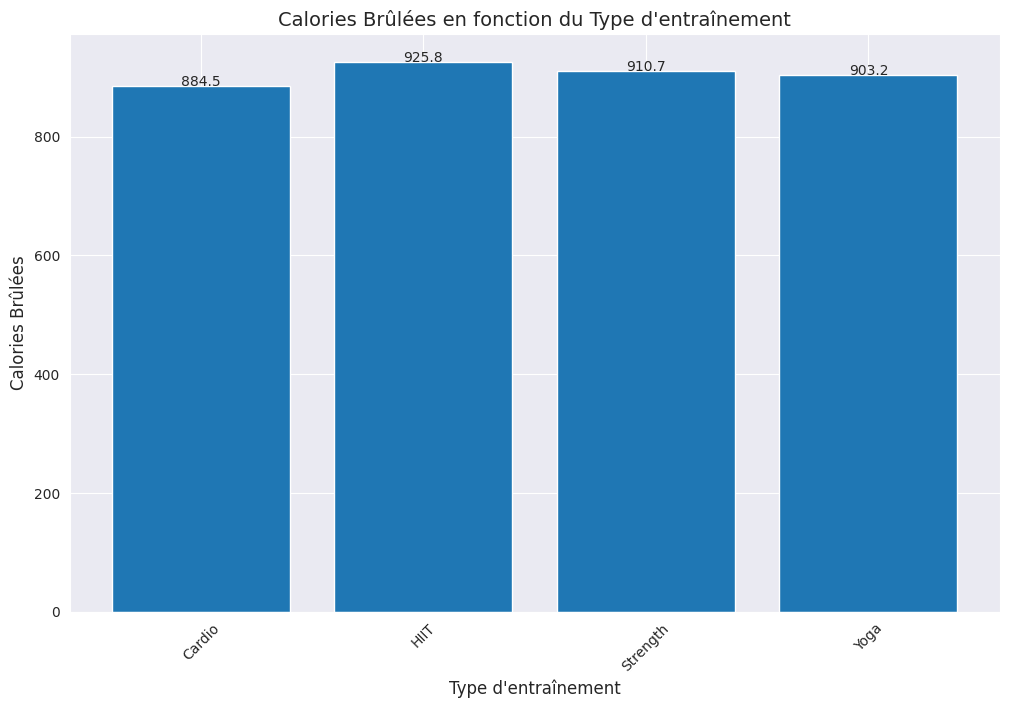

In [ ]:
# Agrégation des données pour le graphique (si nécessaire)
calories_by_workout = df.groupby('Workout_Type')['Calories_Burned'].mean()

# Création du graphique à barres
plt.figure(figsize=(12, 7.5))
plt.bar(calories_by_workout.index, calories_by_workout.values)

for i, v in enumerate(calories_by_workout.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=10)

# Ajout du titre et des labels
plt.title("Calories Brûlées en fonction du Type d'entraînement", fontsize=14)
plt.xlabel("Type d'entraînement", fontsize=12)
plt.ylabel("Calories Brûlées", fontsize=12)

# Rotation des étiquettes si nécessaire
plt.xticks(rotation=45)

# Affichage

plt.show()

Moyenne d'âge par type d'entrainement

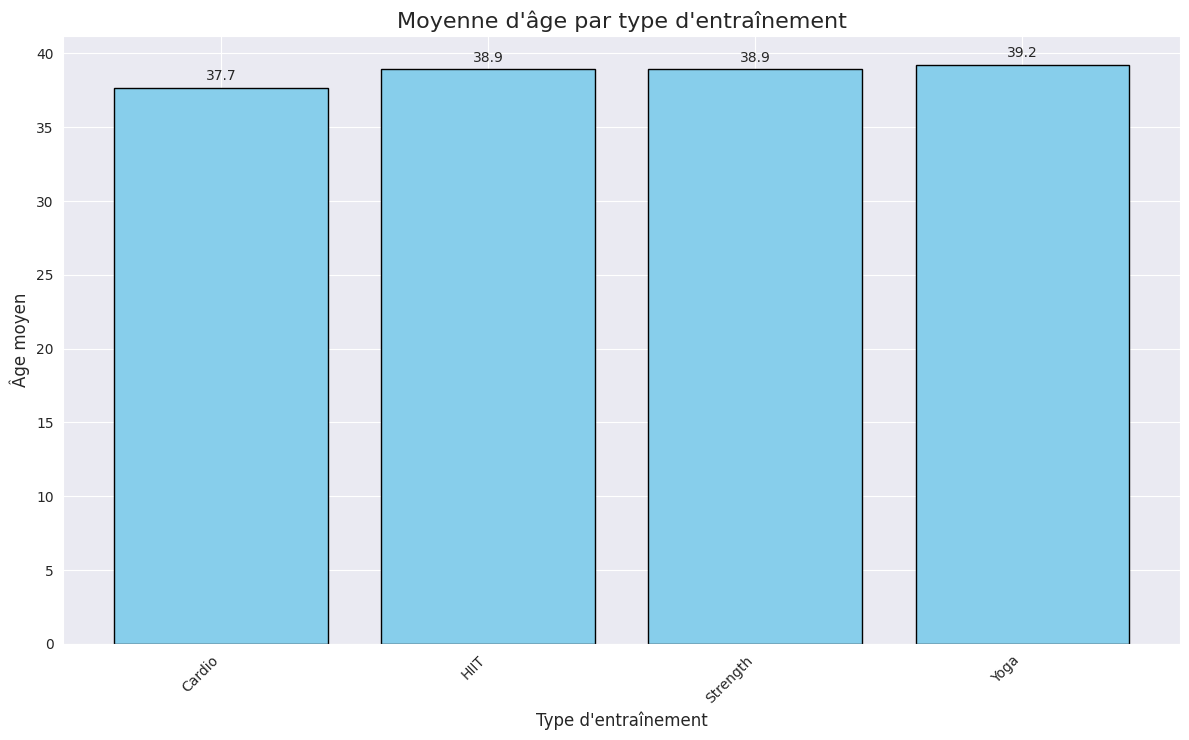

In [ ]:
# Agrégation des données pour le graphique
calories_by_workout = df.groupby('Workout_Type')['Age'].mean()

# Création du graphique à barres
plt.figure(figsize=(12, 7.5))
plt.bar(calories_by_workout.index, calories_by_workout.values, color='skyblue', edgecolor='black')

# Ajout des annotations (valeurs sur les barres)
for i, v in enumerate(calories_by_workout.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=10)

# Ajout du titre et des labels
plt.title("Moyenne d'âge par type d'entraînement", fontsize=16)
plt.xlabel("Type d'entraînement", fontsize=12)
plt.ylabel("Âge moyen", fontsize=12)

# Rotation des étiquettes des axes X pour plus de lisibilité
plt.xticks(rotation=45, ha='right', fontsize=10)

# Application d'un style pour améliorer l'esthétique
plt.style.use('ggplot')

# Affichage
plt.tight_layout()  # Ajuste automatiquement les marges
plt.show()

Calories brûlées et Âge moyen par fréquence

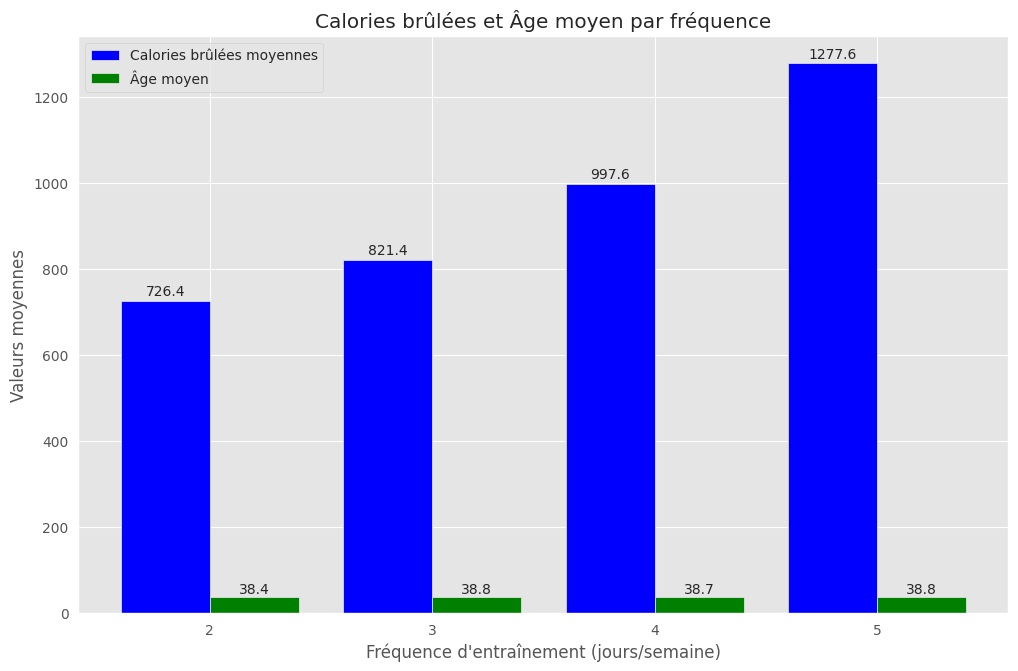

In [ ]:
import numpy as np
# Préparer les données pour un histogramme groupé
grouped_data = df.groupby('Workout_Frequency (days/week)').agg({
    'Calories_Burned': 'mean',
    'Age': 'mean'
})

# Extraire les fréquences, calories moyennes et âge moyen
frequencies = grouped_data.index
mean_calories = grouped_data['Calories_Burned']
mean_age = grouped_data['Age']

# Largeur des barres
bar_width = 0.4
x_positions = np.arange(len(frequencies))

# Tracer l'histogramme groupé avec les valeurs au-dessus des barres
plt.bar(x_positions - bar_width/2, mean_calories, width=bar_width, color='blue', label='Calories brûlées moyennes')
plt.bar(x_positions + bar_width/2, mean_age, width=bar_width, color='green', label='Âge moyen')

# Ajouter les valeurs au-dessus des barres
for i, value in enumerate(mean_calories):
    plt.text(x_positions[i] - bar_width/2, value + 5, f'{value:.1f}', ha='center', va='bottom', fontsize=10)
for i, value in enumerate(mean_age):
    plt.text(x_positions[i] + bar_width/2, value + 0.5, f'{value:.1f}', ha='center', va='bottom', fontsize=10)


# Ajouter les labels, titre et légende
plt.xlabel('Fréquence d\'entraînement (jours/semaine)')
plt.ylabel('Valeurs moyennes')
plt.title('Calories brûlées et Âge moyen par fréquence')
plt.xticks(x_positions, frequencies)
plt.legend()

# Afficher le graphique
plt.show()


Répartition des types d'entraînement

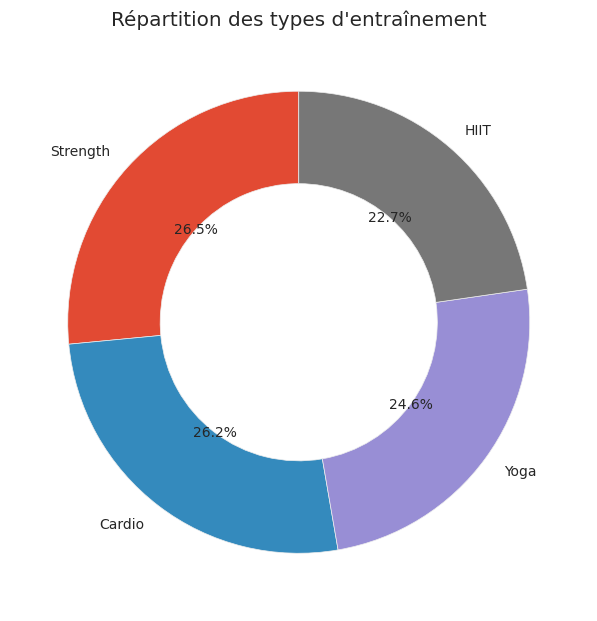

In [ ]:
import matplotlib.pyplot as plt

rep_workout = df['Workout_Type'].value_counts()

# Création du graphique
plt.figure(figsize=(12, 7.5))
plt.pie(rep_workout, labels=rep_workout.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.4})
plt.title('Répartition des types d\'entraînement')

# Afficher le graphique
plt.show()


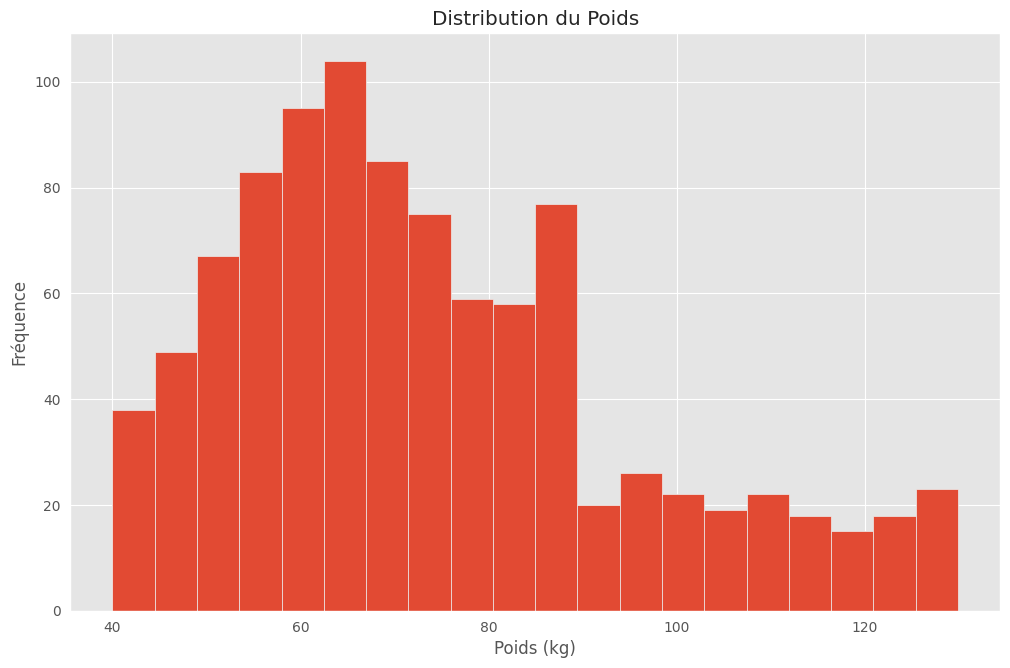

In [ ]:
df['Weight (kg)'].plot(kind='hist', bins=20, title='Distribution du Poids')
plt.xlabel('Poids (kg)')
plt.ylabel('Fréquence')
plt.show()

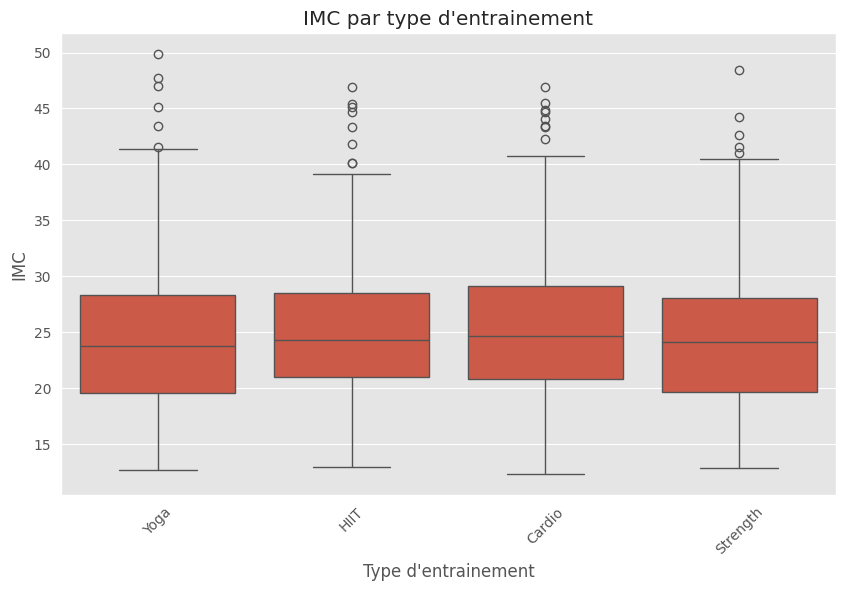

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Workout_Type", y="BMI", data=df)
plt.title("IMC par type d'entrainement")
plt.xlabel("Type d'entrainement")
plt.ylabel("IMC")
plt.xticks(rotation=45)
plt.show()

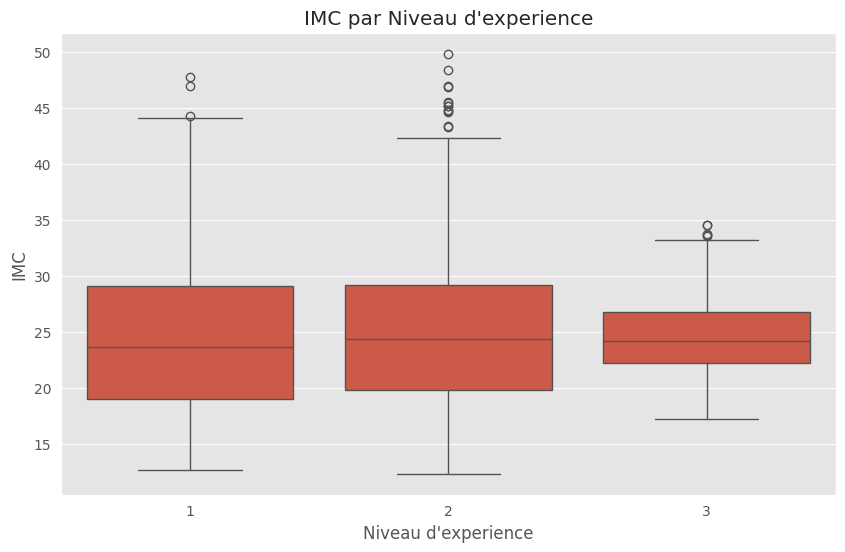

In [ ]:
# Box Plot: BMI by Experience Level
plt.figure(figsize=(10, 6))
sns.boxplot(x="Experience_Level", y="BMI", data=df)
plt.title("IMC par Niveau d'experience")
plt.xlabel("Niveau d'experience")
plt.ylabel("IMC")
plt.show()

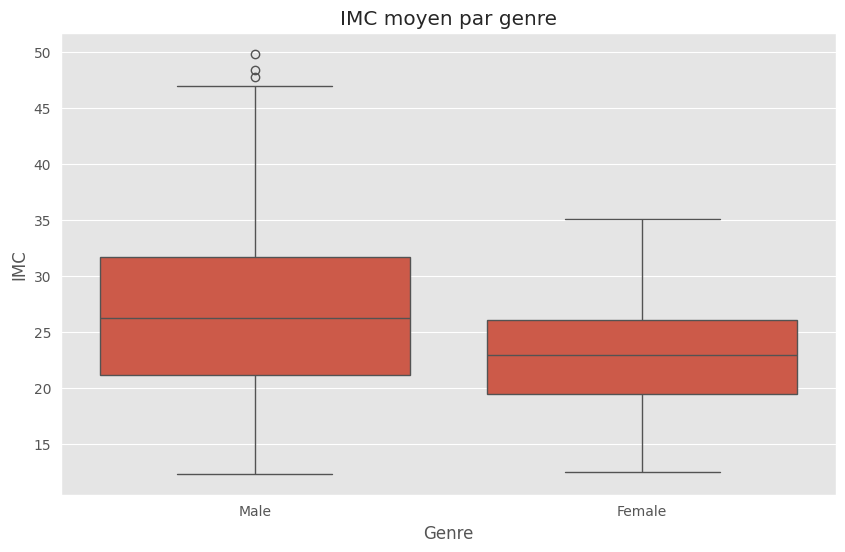

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Gender", y="BMI", data=df)
plt.title("IMC moyen par genre")
plt.xlabel("Genre")
plt.ylabel("IMC")
plt.show()

In [ ]:
quartiles = df['BMI'].quantile([0.25, 0.5, 0.75])
print(quartiles)

0.25    20.11
0.50    24.16
0.75    28.56
Name: BMI, dtype: float64


Quantité de membres dans chaque quartiles de âge

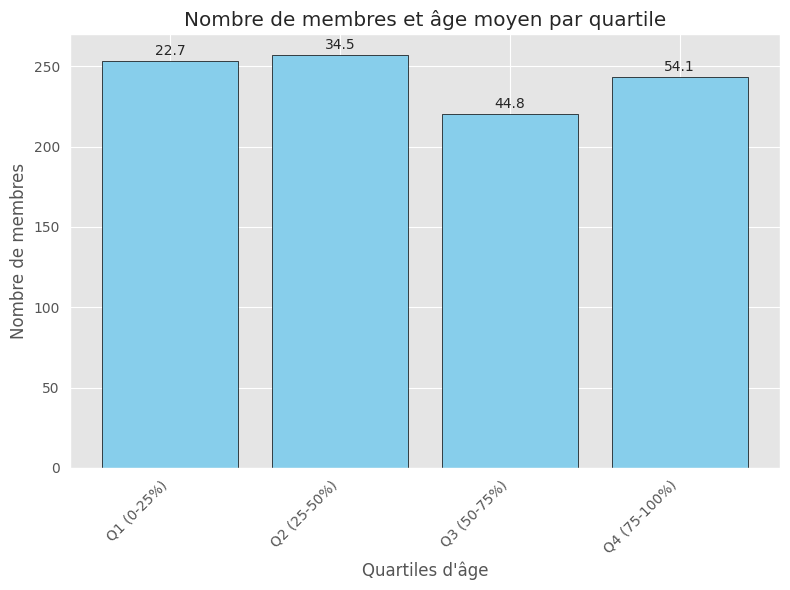

In [ ]:
import matplotlib.pyplot as plt

# Calculer les quartiles de la colonne 'Age'
quartiles = df['Age'].quantile([0.25, 0.5, 0.75])

# Calculer les âges moyens pour chaque quartile
quartile_ages = [
    df[df['Age'] <= quartiles[0.25]]['Age'].mean(),  # Q1 : 0-25%
    df[(df['Age'] > quartiles[0.25]) & (df['Age'] <= quartiles[0.5])]['Age'].mean(),  # Q2 : 25-50%
    df[(df['Age'] > quartiles[0.5]) & (df['Age'] <= quartiles[0.75])]['Age'].mean(),  # Q3 : 50-75%
    df[df['Age'] > quartiles[0.75]]['Age'].mean()  # Q4 : 75-100%
]

# Compter le nombre de membres dans chaque quartile
quartile_counts = [
    len(df[df['Age'] <= quartiles[0.25]]),  # Q1 : 0-25%
    len(df[(df['Age'] > quartiles[0.25]) & (df['Age'] <= quartiles[0.5])]),  # Q2 : 25-50%
    len(df[(df['Age'] > quartiles[0.5]) & (df['Age'] <= quartiles[0.75])]),  # Q3 : 50-75%
    len(df[df['Age'] > quartiles[0.75]])  # Q4 : 75-100%
]

# Tracer le graphique
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)'],
              quartile_counts,
              color='skyblue', edgecolor='black')

# Ajouter les âges moyens au-dessus des barres
for bar, age in zip(bars, quartile_ages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 2, f'{age:.1f}', ha='center', va='bottom', fontsize=10)

# Ajouter des labels et un titre
ax.set_xlabel('Quartiles d\'âge')
ax.set_ylabel('Nombre de membres')
ax.set_title('Nombre de membres et âge moyen par quartile')
plt.xticks(rotation=45, ha='right')  # Rotation des labels pour une meilleure lisibilité
plt.tight_layout()

# Afficher le graphique
plt.show()
